In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [2]:
!pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)


In [3]:
df=pd.read_csv('phones-v1.csv')

In [4]:
df.head()

,Brand,Model,Storage (GB),RAM (GB),Launch,Dimensions,Weight (g),Display Type,Display Size,OS,NFC,Battery (mAh),CPU,Year,PPI Density,Price Range
0,Apple,Apple iPhone X,256,3,2017-11-03,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,high price
1,Apple,Apple iPhone X,256,3,2017-11-03,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,low price
2,Samsung,Samsung Galaxy S9+,64,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,low price
3,Samsung,Samsung Galaxy S9+,128,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,medium price
4,Samsung,Samsung Galaxy S9+,256,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,high price


In [5]:
df.describe()

,Storage (GB),RAM (GB),Weight (g),Display Size,Battery (mAh),Year,PPI Density
count,1011.000000,1011.000000,1011.000000,1011.000000,963.000000,1011.000000,1011.000000
mean,262.741840,7.066271,195.870623,6.530208,4537.714434,2021.754698,404.408506
std,215.449536,2.876769,27.198266,0.433248,774.920157,1.492942,69.283178
min,32.000000,2.000000,135.000000,4.700000,1821.000000,2017.000000,179.000000
25%,128.000000,4.000000,185.000000,6.430000,4352.000000,2021.000000,395.000000
50%,256.000000,6.000000,195.000000,6.600000,5000.000000,2022.000000,402.000000
75%,256.000000,8.000000,204.000000,6.700000,5000.000000,2023.000000,458.000000
max,1000.000000,16.000000,627.000000,12.400000,8000.000000,2024.000000,570.000000


In [6]:
df.isnull().sum()

Brand             0
Model            65
Storage (GB)      0
RAM (GB)          0
Launch            0
Dimensions        0
Weight (g)        0
Display Type      0
Display Size      0
OS                0
NFC               0
Battery (mAh)    48
CPU               0
Year              0
PPI Density       0
Price Range      15
dtype: int64

<Axes: >

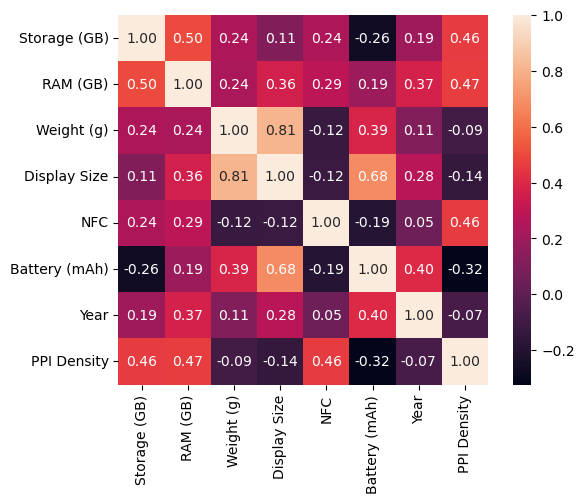

In [7]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", square=True)

In [8]:
df['Brand'].unique()

array(['Apple', 'Samsung', 'Xiaomi'], dtype=object)

In [9]:
dummies=pd.get_dummies(df['Brand'])
df=pd.concat([df,dummies],axis=1)

In [10]:
df.head()

,Brand,Model,Storage (GB),RAM (GB),Launch,Dimensions,Weight (g),Display Type,Display Size,OS,NFC,Battery (mAh),CPU,Year,PPI Density,Price Range,Apple,Samsung,Xiaomi
0,Apple,Apple iPhone X,256,3,2017-11-03,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,high price,True,False,False
1,Apple,Apple iPhone X,256,3,2017-11-03,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,low price,True,False,False
2,Samsung,Samsung Galaxy S9+,64,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,low price,False,True,False
3,Samsung,Samsung Galaxy S9+,128,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,medium price,False,True,False
4,Samsung,Samsung Galaxy S9+,256,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,high price,False,True,False


In [11]:
df.drop(columns=['Brand'],inplace=True)

In [12]:
df.drop(columns='Model',inplace=True)

In [13]:
df.head()

,Storage (GB),RAM (GB),Launch,Dimensions,Weight (g),Display Type,Display Size,OS,NFC,Battery (mAh),CPU,Year,PPI Density,Price Range,Apple,Samsung,Xiaomi
0,256,3,2017-11-03,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,high price,True,False,False
1,256,3,2017-11-03,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,low price,True,False,False
2,64,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,low price,False,True,False
3,128,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,medium price,False,True,False
4,256,6,2018-03-01,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,high price,False,True,False


In [14]:
len(df)

1011

In [16]:
len(df['Launch'].unique())

148

In [17]:
df.drop(columns='Launch',inplace=True)

In [20]:
def preprocess_dims(value):
    if not pd.isna(value):
        vals=value.split('mm')[0].split('x')
        return [float(x) for x in vals]
    return value

In [21]:
df[["Height", "Width", "Thickness"]]=df['Dimensions'].apply(preprocess_dims).tolist()

In [22]:
df.head()

,Storage (GB),RAM (GB),Dimensions,Weight (g),Display Type,Display Size,OS,NFC,Battery (mAh),CPU,Year,PPI Density,Price Range,Apple,Samsung,Xiaomi,Height,Width,Thickness
0,256,3,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,high price,True,False,False,143.6,70.9,7.7
1,256,3,143.6 x 70.9 x 7.7 mm (5.65 x 2.79 x 0.30 in),174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,low price,True,False,False,143.6,70.9,7.7
2,64,6,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,low price,False,True,False,158.1,73.8,8.5
3,128,6,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,medium price,False,True,False,158.1,73.8,8.5
4,256,6,158.1 x 73.8 x 8.5 mm (6.22 x 2.91 x 0.33 in),189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,high price,False,True,False,158.1,73.8,8.5


In [23]:
df.drop(columns=["Dimensions"], inplace=True)

In [25]:
df.head()

,Storage (GB),RAM (GB),Weight (g),Display Type,Display Size,OS,NFC,Battery (mAh),CPU,Year,PPI Density,Price Range,Apple,Samsung,Xiaomi,Height,Width,Thickness
0,256,3,174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,high price,True,False,False,143.6,70.9,7.7
1,256,3,174.0,OLED,5.8,iOS,True,2716.0,Hexa-Core,2017,458,low price,True,False,False,143.6,70.9,7.7
2,64,6,189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,low price,False,True,False,158.1,73.8,8.5
3,128,6,189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,medium price,False,True,False,158.1,73.8,8.5
4,256,6,189.0,AMOLED,6.2,Android,True,3500.0,Octa-Core,2018,529,high price,False,True,False,158.1,73.8,8.5


In [26]:
df = pd.concat([df, pd.get_dummies(df["Display Type"])], axis=1)
df.drop(columns=["Display Type"], inplace=True)

In [27]:
df = pd.concat([df, pd.get_dummies(df["OS"])], axis=1)
df.drop(columns=["OS"], inplace=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Storage (GB)   1011 non-null   int64  
 1   RAM (GB)       1011 non-null   int64  
 2   Weight (g)     1011 non-null   float64
 3   Display Size   1011 non-null   float64
 4   NFC            1011 non-null   bool   
 5   Battery (mAh)  963 non-null    float64
 6   CPU            1011 non-null   object 
 7   Year           1011 non-null   int64  
 8   PPI Density    1011 non-null   int64  
 9   Price Range    996 non-null    object 
 10  Apple          1011 non-null   bool   
 11  Samsung        1011 non-null   bool   
 12  Xiaomi         1011 non-null   bool   
 13  Height         1011 non-null   float64
 14  Width          1011 non-null   float64
 15  Thickness      1011 non-null   float64
 16  AMOLED         1011 non-null   bool   
 17  LCD            1011 non-null   bool   
 18  OLED    

In [29]:
df["NFC"] = df["NFC"].astype(int)

In [31]:
df['CPU']=df['CPU'].map({'Quad-Core':4,'Hexa-Core':6,'Octa-Core':8})

In [32]:
df.head()

,Storage (GB),RAM (GB),Weight (g),Display Size,NFC,Battery (mAh),CPU,Year,PPI Density,Price Range,Apple,Samsung,Xiaomi,Height,Width,Thickness,AMOLED,LCD,OLED,Android,iOS
0,256,3,174.0,5.8,1,2716.0,6,2017,458,high price,True,False,False,143.6,70.9,7.7,False,False,True,False,True
1,256,3,174.0,5.8,1,2716.0,6,2017,458,low price,True,False,False,143.6,70.9,7.7,False,False,True,False,True
2,64,6,189.0,6.2,1,3500.0,8,2018,529,low price,False,True,False,158.1,73.8,8.5,True,False,False,True,False
3,128,6,189.0,6.2,1,3500.0,8,2018,529,medium price,False,True,False,158.1,73.8,8.5,True,False,False,True,False
4,256,6,189.0,6.2,1,3500.0,8,2018,529,high price,False,True,False,158.1,73.8,8.5,True,False,False,True,False


In [34]:
ordinal_encoder=OrdinalEncoder(
    categories=[["low price", "medium price", "high price"]],
    handle_unknown='use_encoded_value',
    unknown_value=np.nan
)

In [35]:
df[["Price Range"]] = ordinal_encoder.fit_transform(df[["Price Range"]])

<Axes: >

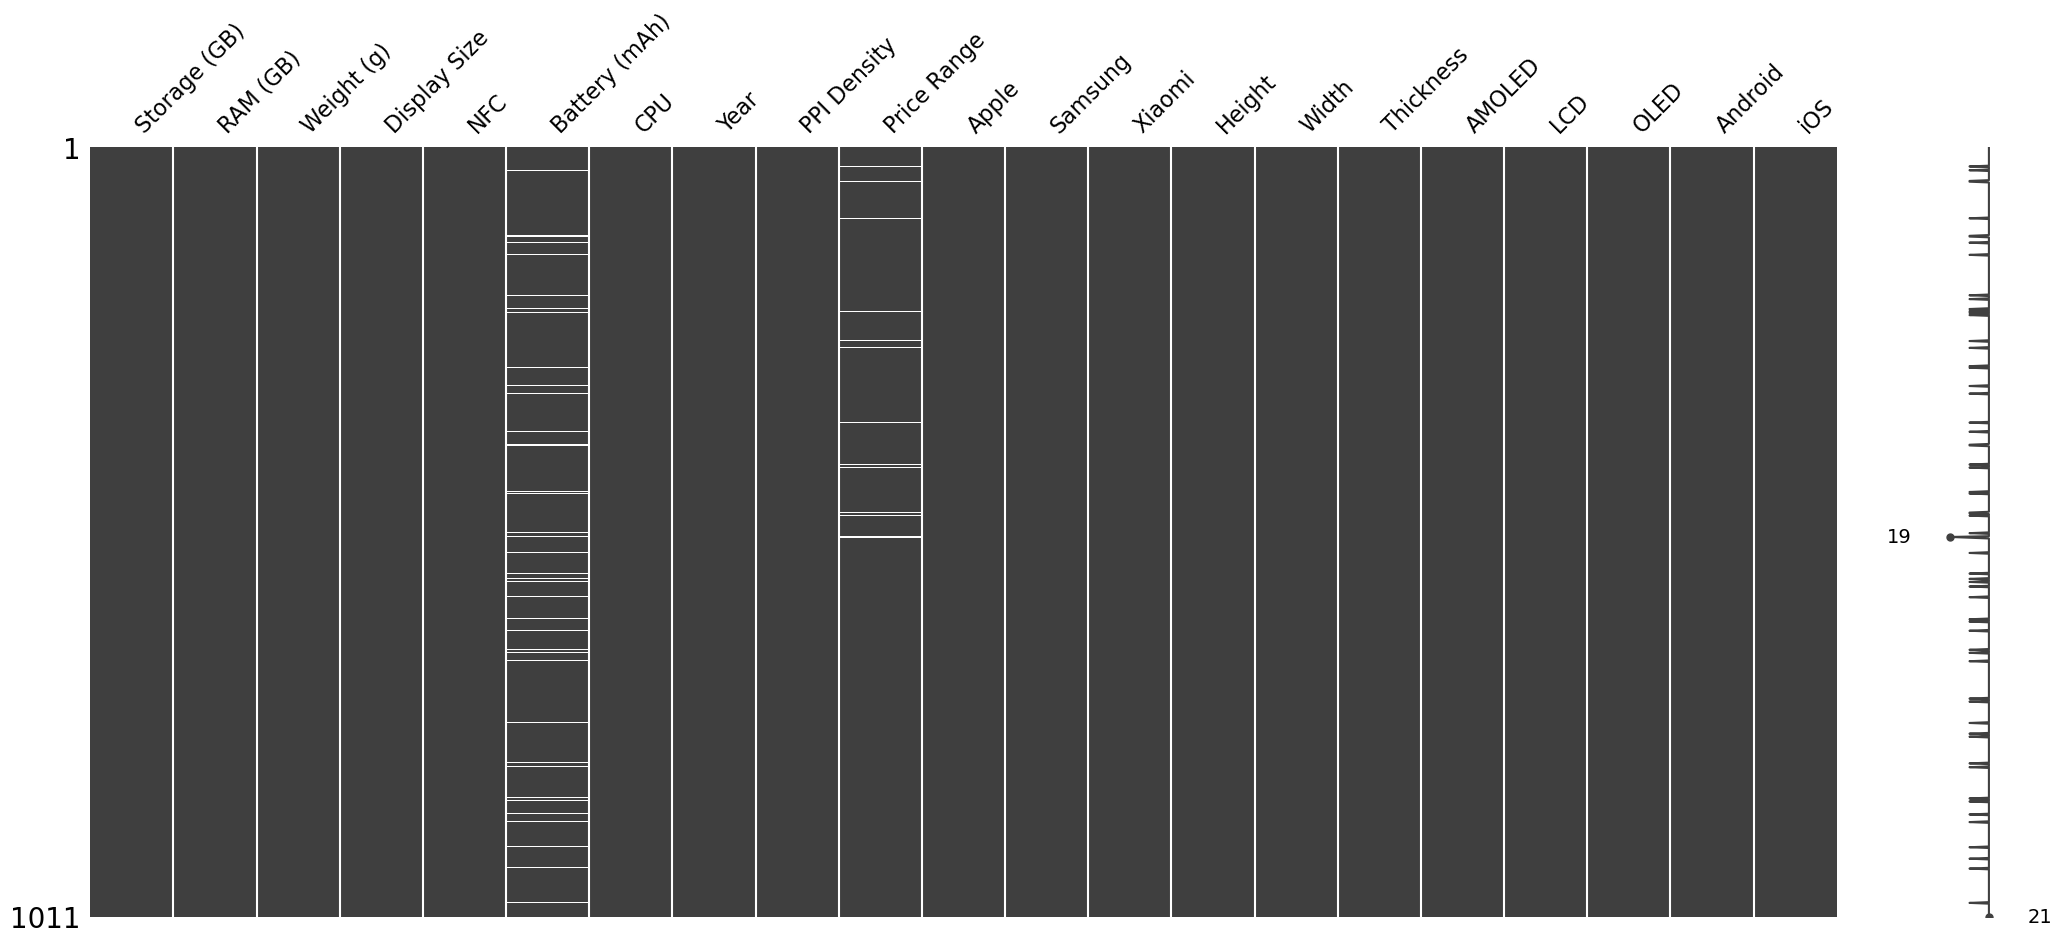

In [39]:
msno.matrix(df)

<Axes: >

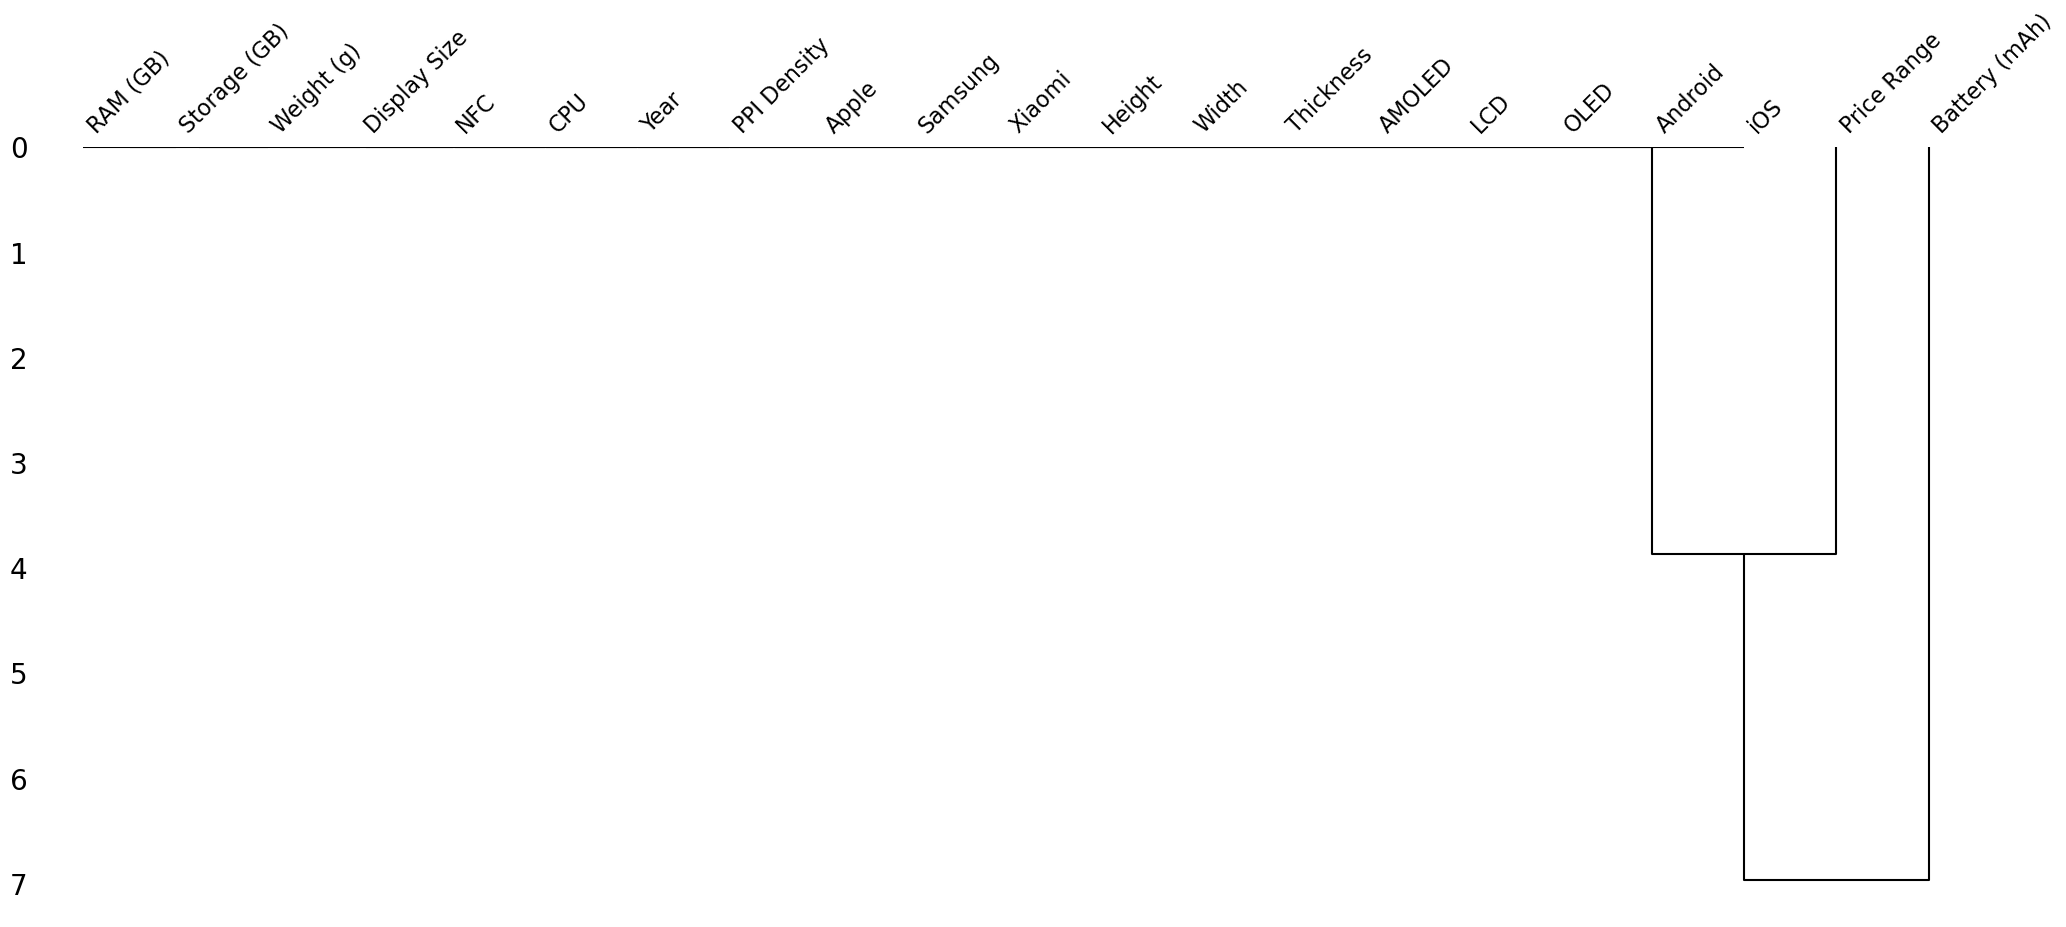

In [40]:
msno.dendrogram(df)

<Axes: >

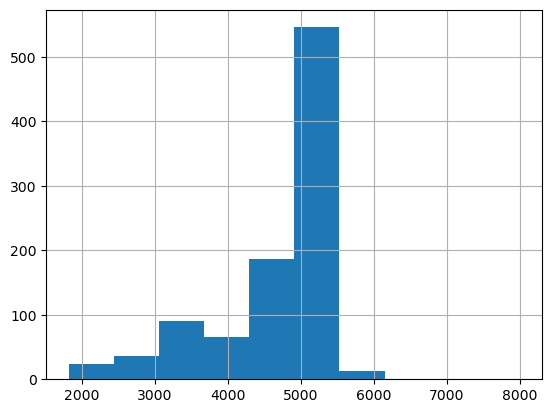

In [41]:
df["Battery (mAh)"].hist()

<Axes: >

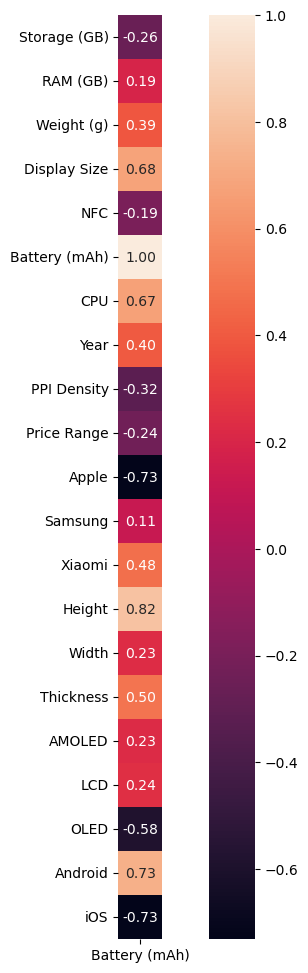

In [42]:
plt.figure(figsize=(12, 12))
sns.heatmap(df.corr(numeric_only=True)[["Battery (mAh)"]], annot=True, fmt=".2f", square=True)

In [43]:
cols = ["Battery (mAh)", "Display Size", "CPU", "Apple", "Height", "Thickness", "OLED", "Android", "iOS"]

In [44]:
iterative_imputer = IterativeImputer()

In [45]:
df[cols] = iterative_imputer.fit_transform(df[cols])

In [46]:
df.isnull().sum()

Storage (GB)      0
RAM (GB)          0
Weight (g)        0
Display Size      0
NFC               0
Battery (mAh)     0
CPU               0
Year              0
PPI Density       0
Price Range      15
Apple             0
Samsung           0
Xiaomi            0
Height            0
Width             0
Thickness         0
AMOLED            0
LCD               0
OLED              0
Android           0
iOS               0
dtype: int64

In [47]:
df.dropna(subset=["Price Range"], axis=0, inplace=True)

In [48]:
df.isnull().sum()

Storage (GB)     0
RAM (GB)         0
Weight (g)       0
Display Size     0
NFC              0
Battery (mAh)    0
CPU              0
Year             0
PPI Density      0
Price Range      0
Apple            0
Samsung          0
Xiaomi           0
Height           0
Width            0
Thickness        0
AMOLED           0
LCD              0
OLED             0
Android          0
iOS              0
dtype: int64

In [49]:
X,y=df.drop(columns=['Price Range']), df['Price Range']

In [50]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [51]:
scaler = MinMaxScaler()

In [52]:
train_X = scaler.fit_transform(train_X)

In [59]:
test_X=scaler.fit_transform(test_X)

In [60]:
classifier = LogisticRegression().fit(train_X, train_y)

In [61]:

pred_y = classifier.predict(test_X)

In [62]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       1.00      0.10      0.18        20
         1.0       0.80      0.97      0.88       156
         2.0       0.56      0.21      0.30        24

    accuracy                           0.80       200
   macro avg       0.79      0.43      0.46       200
weighted avg       0.79      0.80      0.74       200



In [63]:
classifier = KNeighborsClassifier().fit(train_X, train_y)

In [64]:
pred_y = classifier.predict(test_X)

In [65]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       0.60      0.45      0.51        20
         1.0       0.85      0.94      0.89       156
         2.0       0.71      0.42      0.53        24

    accuracy                           0.82       200
   macro avg       0.72      0.60      0.64       200
weighted avg       0.81      0.82      0.81       200



In [66]:
classifier = DecisionTreeClassifier().fit(train_X, train_y)

In [67]:
pred_y = classifier.predict(test_X)

In [68]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       0.33      0.65      0.44        20
         1.0       0.85      0.78      0.82       156
         2.0       0.56      0.42      0.48        24

    accuracy                           0.72       200
   macro avg       0.58      0.62      0.58       200
weighted avg       0.77      0.72      0.74       200



In [69]:
param_grid = {
    "criterion": ["entropy", "gini"],
    "max_depth": [None, 1, 2, 3, 4],
}

In [70]:
classifier = DecisionTreeClassifier()

In [71]:
grid_search=GridSearchCV(classifier,param_grid,scoring='f1_weighted',cv=5)

In [72]:
grid_search.fit(train_X, train_y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [None, 1, 2, 3, 4]},
             scoring='f1_weighted')

In [73]:
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 4}

In [74]:
pred_y = grid_search.predict(test_X)

In [75]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       1.00      0.05      0.10        20
         1.0       0.81      0.97      0.89       156
         2.0       0.67      0.33      0.44        24

    accuracy                           0.81       200
   macro avg       0.83      0.45      0.48       200
weighted avg       0.81      0.81      0.75       200

